# Assignment 3: Binomial Probability — Manual Implementation and Validation

Develop a Python function to manually calculate binomial probability using the binomial
probability formula, without using any built-in probability distribution functions.
Validate the results using SciPy and visualize the probability distribution using
Matplotlib.

Solve the following using the manual implementation:

1. A computer network transmits 20 independent data packets. Due to network congestion,
   the probability that a packet is successfully delivered is 0.9. Find the probability that
   a) exactly 17 packets are delivered successfully, and
   b) at least 18 packets are delivered successfully.
2. A software testing team knows from previous testing that the probability of detecting a
   particular type of bug in a test case is 0.15. If 12 independent test cases are executed,
   determine the probability of detecting the bug in exactly 3 test cases. Also interpret
   what the result means for the testing team.

**Name:** Ishan Kulkarni
**Branch:** CSSE-B
**Roll no.:** 32

In [1]:
import matplotlib.pyplot as plt
from scipy.stats import binom
import pandas as pd

## Manual Binomial Probability Function

The binomial formula for exactly $k$ successes out of $n$ independent trials, each with success probability $p$:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad \binom{n}{k} = \frac{n!}{k!(n-k)!}$$

Factorial, combination, and the PMF are all built from scratch below — no `scipy.stats`, no `numpy` distribution calls, nothing pre-packaged.

In [2]:
def fun_factorial(n):
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


def fun_combination(n, k):
    return fun_factorial(n) / (fun_factorial(k) * fun_factorial(n - k))


def fun_binomial_pmf(n, k, p):
    """P(X = k) for X ~ Binomial(n, p), computed by hand."""
    return fun_combination(n, k) * (p ** k) * ((1 - p) ** (n - k))


def fun_binomial_at_least(n, k_min, p):
    """P(X >= k_min) for X ~ Binomial(n, p), summed term by term."""
    return sum(fun_binomial_pmf(n, k, p) for k in range(k_min, n + 1))

## Problem 1: Network Packet Delivery

20 packets, each with a 0.9 chance of getting through.

**a)** $P(X = 17)$
**b)** $P(X \geq 18)$

In [3]:
n1, p1 = 20, 0.9

# a) exactly 17 delivered
manual_p1a = fun_binomial_pmf(n1, 17, p1)

# b) at least 18 delivered
manual_p1b = fun_binomial_at_least(n1, 18, p1)

print(f"a) P(X = 17)  [manual] : {manual_p1a:.6f}")
print(f"b) P(X >= 18) [manual] : {manual_p1b:.6f}")

a) P(X = 17)  [manual] : 0.190120
b) P(X >= 18) [manual] : 0.676927


### Validation against SciPy

In [4]:
scipy_p1a = binom.pmf(17, n1, p1)
scipy_p1b = binom.sf(17, n1, p1)   # P(X > 17) = P(X >= 18)

print(f"a) P(X = 17)  [SciPy]  : {scipy_p1a:.6f}   | difference: {abs(manual_p1a - scipy_p1a):.2e}")
print(f"b) P(X >= 18) [SciPy]  : {scipy_p1b:.6f}   | difference: {abs(manual_p1b - scipy_p1b):.2e}")

a) P(X = 17)  [SciPy]  : 0.190120   | difference: 1.11e-16
b) P(X >= 18) [SciPy]  : 0.676927   | difference: 0.00e+00


### Visualizing the Distribution

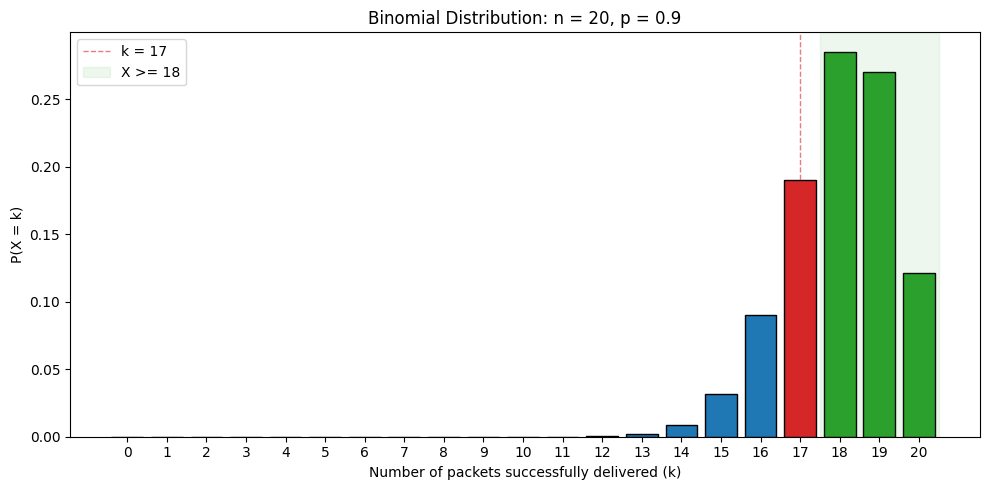

In [5]:
k_values_1 = list(range(0, n1 + 1))
pmf_values_1 = [fun_binomial_pmf(n1, k, p1) for k in k_values_1]

colors_1 = []
for k in k_values_1:
    if k == 17:
        colors_1.append('#d62728')      # highlight exactly 17
    elif k >= 18:
        colors_1.append('#2ca02c')      # highlight at least 18
    else:
        colors_1.append('#1f77b4')

plt.figure(figsize=(10, 5))
plt.bar(k_values_1, pmf_values_1, color=colors_1, edgecolor='black')
plt.title(f"Binomial Distribution: n = {n1}, p = {p1}")
plt.xlabel("Number of packets successfully delivered (k)")
plt.ylabel("P(X = k)")
plt.xticks(k_values_1)
plt.axvline(x=17, color='#d62728', linestyle='--', linewidth=1, alpha=0.6, label='k = 17')
plt.axvspan(17.5, n1 + 0.5, color='#2ca02c', alpha=0.08, label='X >= 18')
plt.legend()
plt.tight_layout()
plt.show()

## Problem 2: Bug Detection Across Test Cases

12 test cases, each with a 0.15 chance of catching the bug. Find $P(X = 3)$.

In [6]:
n2, p2 = 12, 0.15

manual_p2 = fun_binomial_pmf(n2, 3, p2)
scipy_p2 = binom.pmf(3, n2, p2)

print(f"P(X = 3)  [manual] : {manual_p2:.6f}")
print(f"P(X = 3)  [SciPy]  : {scipy_p2:.6f}   | difference: {abs(manual_p2 - scipy_p2):.2e}")

P(X = 3)  [manual] : 0.171976
P(X = 3)  [SciPy]  : 0.171976   | difference: 8.33e-17


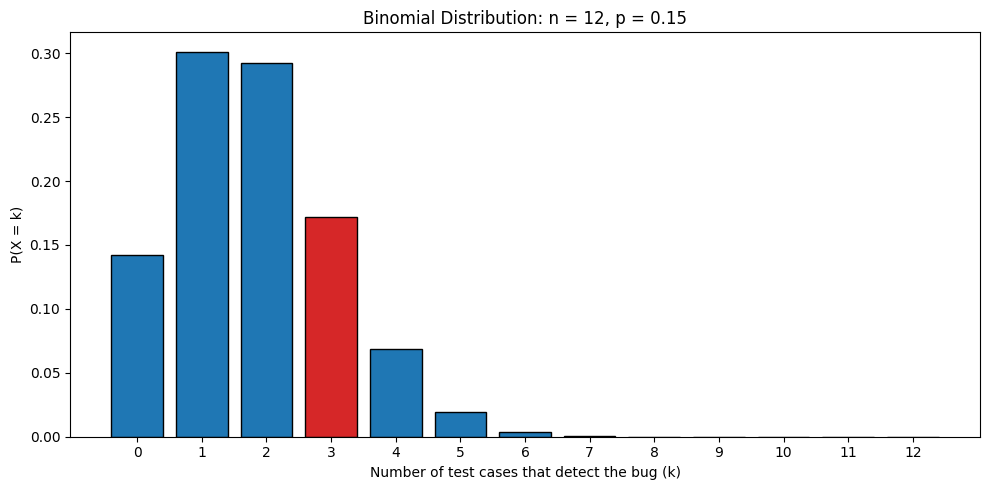

In [7]:
k_values_2 = list(range(0, n2 + 1))
pmf_values_2 = [fun_binomial_pmf(n2, k, p2) for k in k_values_2]
colors_2 = ['#d62728' if k == 3 else '#1f77b4' for k in k_values_2]

plt.figure(figsize=(10, 5))
plt.bar(k_values_2, pmf_values_2, color=colors_2, edgecolor='black')
plt.title(f"Binomial Distribution: n = {n2}, p = {p2}")
plt.xlabel("Number of test cases that detect the bug (k)")
plt.ylabel("P(X = k)")
plt.xticks(k_values_2)
plt.tight_layout()
plt.show()

**What this means for the testing team:** with a 0.15 hit rate, the expected number of test cases that catch the bug out of 12 is $12 \times 0.15 = 1.8$. Landing on exactly 3 is above that average, but it's not even the single most likely outcome — both $k = 1$ and $k = 2$ carry more probability on the chart. In plain terms, this bug is easy to miss. A team that runs the suite once has a real shot at walking away thinking the code is clean when the bug is still sitting there. That's the usual case for running things more than once, or writing a test aimed squarely at this bug instead of hoping a generic pass trips over it.

## Summary — Manual vs. SciPy

In [8]:
summary = pd.DataFrame({
    "Problem": [
        "1a) P(X = 17), n=20, p=0.9",
        "1b) P(X >= 18), n=20, p=0.9",
        "2) P(X = 3), n=12, p=0.15"
    ],
    "Manual": [manual_p1a, manual_p1b, manual_p2],
    "SciPy": [scipy_p1a, scipy_p1b, scipy_p2]
})
summary["Absolute Difference"] = (summary["Manual"] - summary["SciPy"]).abs()
summary

,Problem,Manual,SciPy,Absolute Difference
0,"1a) P(X = 17), n=20, p=0.9",0.190120,0.190120,1.110223e-16
1,"1b) P(X >= 18), n=20, p=0.9",0.676927,0.676927,0.000000e+00
2,"2) P(X = 3), n=12, p=0.15",0.171976,0.171976,8.326673e-17


## Wrapping Up

The manual PMF lines up with SciPy to well within floating-point rounding on all three numbers, so the hand-rolled factorial, combination, and PMF functions are doing exactly what the formula says they should.

The two problems also make a nice contrast. Packet delivery has a high success rate (p = 0.9), so the distribution leans hard toward the top end — 17 through 20 are all fairly likely, and "at least 18" ends up covering a big chunk of the total probability. Bug detection runs the other way: p = 0.15 skews everything toward small counts, with 0 or 1 detections most likely and the tail dropping off fast. Same formula, same code, completely different shape once p moves.